# Homework 3: Download and analyze any data using tools you learned in class

### IMPORTANT: Save your notebook and files (if you import locally) 
### IMPORTANT: See my example data folder: data/hw/hw_3/cory-baird
### **HW Requirements**

- **Relative Paths Only**
  - Use relative paths from the project root (e.g., `data/hw/hw_3/student-name/data.csv`).
  - Never hardcode absolute paths specific to your local machine (e.g., `/Users/username/...`).
- **File Size Limit**
  - Any committed dataset must be reasonable in size (strictly under 10 megabytes).
    - If you have to filter the dataset (to make it smaller) and upload a smaller version

- **Dataset Selection**
  - Select a policy-relevant dataset with at least 50 observations (e.g., 50 states, countries, or time periods) for meaningful analysis.
  - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Data Acquisition**
  - You are highly encouraged to fetch data programmatically using an API (e.g. using `requests` with World Bank, US Census, or other public APIs) or load a direct public URL.

  - Alternatively, you may upload a local file, provided it is committed to your repository.
    - If you read csv/parquet etc use relative paths such as `data/hw/hw_3/student-name/data.csv`.
    - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Reproducibility**
  - Commit both this notebook and the dataset so that your grader can run all cells from top to bottom out-of-the-box.

## IMPORTANT

---
### **Objectives**
- Select, acquire, and load a policy-relevant dataset of your choice.
- Apply clean code principles (environment checks, Python collections, standardized variable naming).
- Preprocess and standardize columns using Pandas techniques.
- Programmatically merge your primary dataset with a secondary source.
- Segment your data and run custom aggregations (using groupby or custom grouping strategies).
- Create customized visualizations and run exploratory regression analysis to discover policy insights.

### **Concept Reference Map**
- **Data Acquisition**: APIs (`requests` library), reading Parquet/CSV (Week 2/3 basics, Week 4 `1-visualization_basics.ipynb`)
- **Data Manipulation**: Selecting, renaming columns, filtering (`query()`), dropping NaNs (Week 4 `1-visualization_basics.ipynb`)
- **Aggregation**: Groupby, descriptive statistics (`describe()`, `mean()`) (Week 4 `1-visualization_basics.ipynb`)
- **Data Merging**: Pandas `merge()` matching indices or keys (Week 4 `2-merging_practice.ipynb`)
- **Visualization**: Scatter plots, line/bar charts, customization (Week 4 / Week 6 `1-regression.ipynb`)
- **Modeling**: Simple Linear Regression (`statsmodels`), line of best fit (Week 6 `1-regression.ipynb`)

---

### **Part 1: Data Acquisition & Environment Preparation**

- **Environment Setup**
  - Use python's `os` library (as reviewed in Week 3) to print your current working directory (`os.getcwd()`) and list the files in your project directory (`os.listdir()`) to ensure your paths are configured correctly.
- **Acquisition Steps**
  - Programmatically fetch data using `requests` or read directly from a public URL using Pandas.
  - If loading a committed local dataset, load it using a relative path.
- **Code Requirements**
  - Define variables using standardized, descriptive names.
  - Keep all function and method arguments on a single line.
  - Do not use docstrings (`""" """`) or runtime type checking in your helper methods.

In [1]:
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt


# You can use example datasets here docs/example_datasets.md

# 1. Print environment details (working directory and local folder contents)
while not os.path.exists("data"):
    os.chdir("..")

print("Working directory:", os.getcwd())
print("Folder contents:", os.listdir())

# 2. Acquire and load primary datasets
low_bw = pd.read_csv("data/hw/hw_3/low_bw.csv")
parental_leave = pd.read_csv("data/hw/hw_3/parental_leave.csv")


print("low_bw shape:", low_bw.shape)
print("parental_leave shape:", parental_leave.shape)

Working directory: c:\Users\33493\OneDrive\Documents\GitHub\datascience-publicpolicy-2026
Folder contents: ['.git', '.gitignore', 'data', 'docs', 'environment.yml', 'notebooks', 'pyproject.toml', 'README.md', 'references', 'requirements.txt', 'src', 'test.ipynb', 'uv.lock']
low_bw shape: (673, 44)
parental_leave shape: (379, 26)


### **Dataset Context & Relevance**

- **Dataset Source**
  - Specify the source of your dataset (e.g., API name, public organization, or website URL).

  https://data-explorer.oecd.org/vis?tm=maternity%20leave&pg=0&snb=4&df[ds]=dsDisseminateFinalDMZ&df[id]=DSD_CWB%40DF_CWB&df[ag]=OECD.WISE.CWB&df[vs]=1.0&dq=.C1_4%2BC1_5.C1&lom=LASTNPERIODS&lo=5&to[TIME_PERIOD]=false&vw=tb&isAvailabilityDisabled=falserite 

### **Part 2: Data Cleaning & Preprocessing**

- **Data Inspection**
  - Inspect column names, data types, and non-null counts using `.info()` and `.head()`.
- **Preprocessing Tasks**
  - Select a subset of columns necessary for your policy inquiry.
  - Standardize column names to a clean formatting (preferably `snake_case` or another consistent style).
  - Identify and handle missing values (`NaN`s) by dropping or filling them.
- **Python Grammar Tip**
  - You are encouraged to use a Python dictionary (as reviewed in Week 2 & 3) to map and rename your column names cleanly.

In [2]:
# 1. Inspect data structure using pandas methods
print("=== low_bw ===")
low_bw.info()
display(low_bw.head())

print("=== parental_leave ===")
parental_leave.info()
display(parental_leave.head())

=== low_bw ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 673 entries, 0 to 672
Data columns (total 44 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   STRUCTURE                   673 non-null    object 
 1   STRUCTURE_ID                673 non-null    object 
 2   STRUCTURE_NAME              673 non-null    object 
 3   ACTION                      673 non-null    object 
 4   REF_AREA                    673 non-null    object 
 5   Reference area              673 non-null    object 
 6   FREQ                        673 non-null    object 
 7   Frequency of observation    673 non-null    object 
 8   MEASURE                     673 non-null    object 
 9   Measure                     673 non-null    object 
 10  UNIT_MEASURE                673 non-null    object 
 11  Unit of measure             673 non-null    object 
 12  AGE                         673 non-null    object 
 13  Age                 

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,FREQ,Frequency of observation,MEASURE,Measure,...,DECIMALS,Decimals,OBS_STATUS,Observation status,OBS_STATUS2,Observation status 2,OBS_STATUS3,Observation status 3,UNIT_MULT,Unit multiplier
0,DATAFLOW,OECD.ELS.HD:DSD_HEALTH_STAT@DF_IH_LB(1.1),Infant health: low birthweight,I,AUT,Austria,A,Annual,LOWB,Low birthweight,...,1,One,NaN,NaN,NaN,NaN,NaN,NaN,0,Units
1,DATAFLOW,OECD.ELS.HD:DSD_HEALTH_STAT@DF_IH_LB(1.1),Infant health: low birthweight,I,CHL,Chile,A,Annual,LOWB,Low birthweight,...,1,One,NaN,NaN,NaN,NaN,NaN,NaN,0,Units
2,DATAFLOW,OECD.ELS.HD:DSD_HEALTH_STAT@DF_IH_LB(1.1),Infant health: low birthweight,I,KOR,Korea,A,Annual,LOWB,Low birthweight,...,1,One,NaN,NaN,NaN,NaN,NaN,NaN,0,Units
3,DATAFLOW,OECD.ELS.HD:DSD_HEALTH_STAT@DF_IH_LB(1.1),Infant health: low birthweight,I,LUX,Luxembourg,A,Annual,LOWB,Low birthweight,...,1,One,NaN,NaN,NaN,NaN,NaN,NaN,0,Units
4,DATAFLOW,OECD.ELS.HD:DSD_HEALTH_STAT@DF_IH_LB(1.1),Infant health: low birthweight,I,MEX,Mexico,A,Annual,LOWB,Low birthweight,...,1,One,NaN,NaN,NaN,NaN,NaN,NaN,0,Units


=== parental_leave ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 379 entries, 0 to 378
Data columns (total 26 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   STRUCTURE           379 non-null    object 
 1   STRUCTURE_ID        379 non-null    object 
 2   STRUCTURE_NAME      379 non-null    object 
 3   ACTION              379 non-null    object 
 4   REF_AREA            379 non-null    object 
 5   Reference area      379 non-null    object 
 6   MEASURE             379 non-null    object 
 7   Measure             379 non-null    object 
 8   DOMAIN              379 non-null    object 
 9   Domain              379 non-null    object 
 10  TIME_PERIOD         379 non-null    int64  
 11  Time period         0 non-null      float64
 12  OBS_VALUE           379 non-null    float64
 13  Observation value   0 non-null      float64
 14  OBS_STATUS          379 non-null    object 
 15  Observation status  379 non-null  

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,MEASURE,Measure,DOMAIN,Domain,...,UNIT_MULT,Unit multiplier,UNIT_MEASURE,Unit of measure,BASE_PER,Base period,DECIMALS,Decimals,POP_GROUP,Population group
0,DATAFLOW,OECD.WISE.CWB:DSD_CWB@DF_CWB(1.0),Child well-being,I,MEX,Mexico,C1_5,Total length of paid paternity and parental le...,C1,Family policies,...,0,Units,WK,Weeks,NaN,NaN,1,One,_Z,Not applicable
1,DATAFLOW,OECD.WISE.CWB:DSD_CWB@DF_CWB(1.0),Child well-being,I,AUS,Australia,C1_4,Total length of paid maternity and parental le...,C1,Family policies,...,0,Units,WK,Weeks,NaN,NaN,1,One,_Z,Not applicable
2,DATAFLOW,OECD.WISE.CWB:DSD_CWB@DF_CWB(1.0),Child well-being,I,AUS,Australia,C1_4,Total length of paid maternity and parental le...,C1,Family policies,...,0,Units,WK,Weeks,NaN,NaN,1,One,_Z,Not applicable
3,DATAFLOW,OECD.WISE.CWB:DSD_CWB@DF_CWB(1.0),Child well-being,I,AUS,Australia,C1_4,Total length of paid maternity and parental le...,C1,Family policies,...,0,Units,WK,Weeks,NaN,NaN,1,One,_Z,Not applicable
4,DATAFLOW,OECD.WISE.CWB:DSD_CWB@DF_CWB(1.0),Child well-being,I,AUS,Australia,C1_4,Total length of paid maternity and parental le...,C1,Family policies,...,0,Units,WK,Weeks,NaN,NaN,1,One,_Z,Not applicable


In [3]:
# 2. Rename columns and select a clean subset


low_bw_clean = (
    low_bw[['REF_AREA', 'TIME_PERIOD', 'OBS_VALUE']]
    .rename(columns={'REF_AREA': 'country_code', 'TIME_PERIOD': 'year', 'OBS_VALUE': 'lowb_pct'})
)

#pivot fathers/mothers leave into separate columns
measure_map = {
    'Total length of paid paternity and parental leave reserved for fathers': 'leave_fathers',
    'Total length of paid maternity and parental leave available to mothers': 'leave_mothers'
}

parental_leave_clean = (
    parental_leave[parental_leave['Measure'].isin(measure_map)]
    .assign(Measure=lambda df: df['Measure'].map(measure_map))
    .pivot_table(index=['REF_AREA',  'TIME_PERIOD'], columns='Measure', values='OBS_VALUE')
    .reset_index()
    .rename(columns={'REF_AREA': 'country_code',  'TIME_PERIOD': 'year'})
)
parental_leave_clean.columns.name = None

display(low_bw_clean.head())
display(parental_leave_clean.head())

,country_code,year,lowb_pct
0,AUT,2021,5.9
1,CHL,2010,5.9
2,KOR,2016,5.9
3,LUX,2022,5.9
4,MEX,2016,5.9


,country_code,year,leave_fathers,leave_mothers
0,AUS,2017,2.0,18.0
1,AUS,2018,2.0,18.0
2,AUS,2019,2.0,18.0
3,AUS,2020,2.0,18.0
4,AUS,2021,2.0,18.0


In [4]:
# 4. Handle missing values (NaNs) if necessary

print("=== low_bw_clean missing values ===")
print(low_bw_clean.isnull().sum())

print("=== parental_leave_clean missing values ===")
print(parental_leave_clean.isnull().sum())

=== low_bw_clean missing values ===
country_code    0
year            0
lowb_pct        0
dtype: int64
=== parental_leave_clean missing values ===
country_code     0
year             0
leave_fathers    0
leave_mothers    1
dtype: int64


### **Merge Verification**

- **Merge Key**
  - country code and year
- **Observations Retained**
  - 185

In [5]:
merged = low_bw_clean.merge(parental_leave_clean, on=['country_code', 'year'], how='inner')

print("Merged shape:", merged.shape)
display(merged.head())

Merged shape: (185, 5)


,country_code,year,lowb_pct,leave_fathers,leave_mothers
0,AUT,2021,5.9,13.0,60.0
1,NLD,2017,5.9,0.4,16.0
2,SVN,2019,5.9,4.3,52.1
3,CHE,2020,5.9,2.0,14.0
4,CHE,2021,5.9,2.0,14.0


In [6]:

yearly_stats = (
    merged.groupby('year')[['lowb_pct', 'leave_fathers', 'leave_mothers']]
    .agg(['mean', 'median', 'min', 'max'])
    .round(2)
)

display(yearly_stats)

lowb_pct                  leave_fathers                   leave_mothers  \
         mean median  min  max          mean median  min   max          mean   
year                                                                           
2017     6.61    6.6  3.8  9.4          7.95    2.0  0.0  52.6         53.22   
2018     6.55    6.7  3.6  9.6          8.05    2.0  0.0  52.6         52.06   
2019     6.56    6.7  4.0  9.5          8.49    2.0  0.0  52.6         52.01   
2020     6.29    6.5  3.6  9.2          8.92    2.0  0.0  54.0         50.14   
2021     6.44    6.5  3.7  9.9          9.41    4.0  0.0  54.0         49.81   

                         
     median  min    max  
year                     
2017   42.0  0.0  166.0  
2018   43.0  0.0  166.0  
2019   43.0  0.0  166.0  
2020   43.0  0.0  164.0  
2021   42.5  0.0  164.0

- *Extra Credit: Write your economic or policy related interpretation here*

### **Part 5: Visualization & Regression Modeling**

- **Visualization Requirements**
  - Generate at least two fully customized, beautiful Matplotlib plots.
  - **Plot 1**: A bar chart or line chart showing aggregated subgroups from Part 4.
  - **Plot 2**: A scatter plot representing the relationship between two primary indicators.
  - **Customizations**: Make sure to customize titles, axis labels, gridlines, colors, and markers for a clean and readable style.
- **Exploratory Modeling**
  - Fit a simple linear regression using `statsmodels` (Level-Level, Log-Level, or Log-Log as discussed in Week 6) to model the policy relationship.
  - Plot the line of best fit directly over your scatter plot.
  - Print the summary table and interpret the slope coefficient.

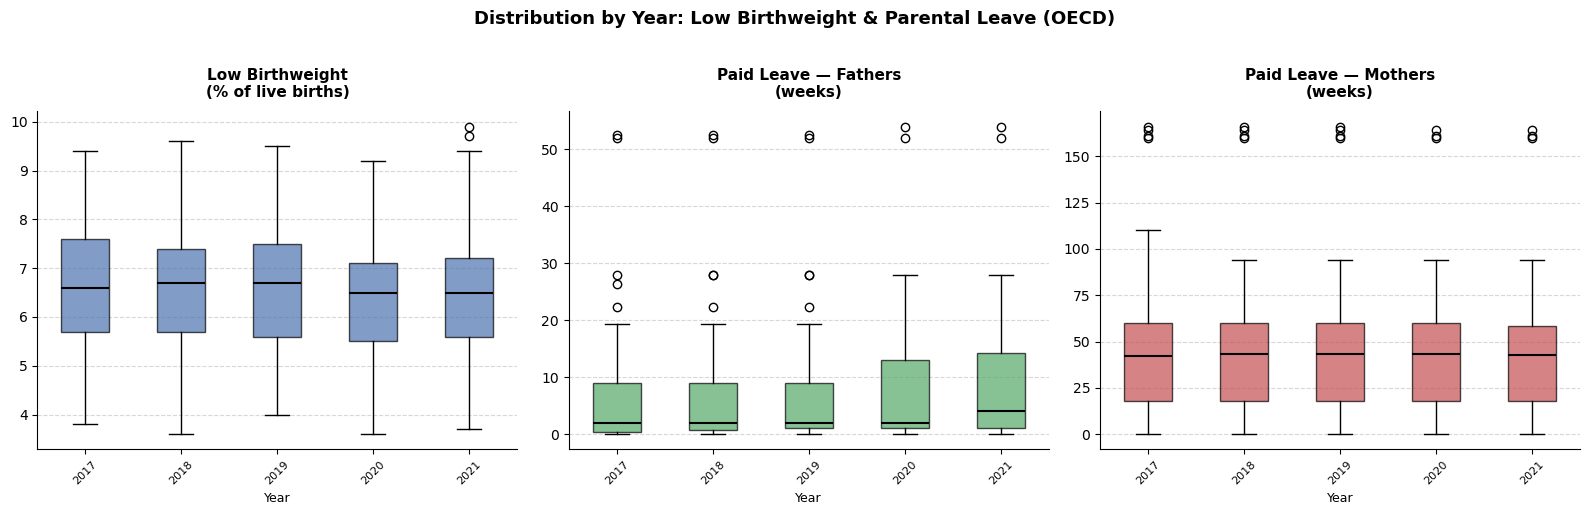

In [7]:
# Plot 1: Customized bar chart or line chart of aggregated subgroups
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

variables = {
    'lowb_pct': 'Low Birthweight\n(% of live births)',
    'leave_fathers': 'Paid Leave — Fathers\n(weeks)',
    'leave_mothers': 'Paid Leave — Mothers\n(weeks)'
}
colors = ['#4C72B0', '#55A868', '#C44E52']
years = sorted(merged['year'].unique())

for ax, (var, label), color in zip(axes, variables.items(), colors):
    groups = [merged.loc[merged['year'] == yr, var].dropna().values for yr in years]
    bp = ax.boxplot(groups, patch_artist=True, medianprops=dict(color='black', linewidth=1.5))
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels(years, rotation=45, fontsize=8)
    ax.set_title(label, fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel('Year', fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Distribution by Year: Low Birthweight & Parental Leave (OECD)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

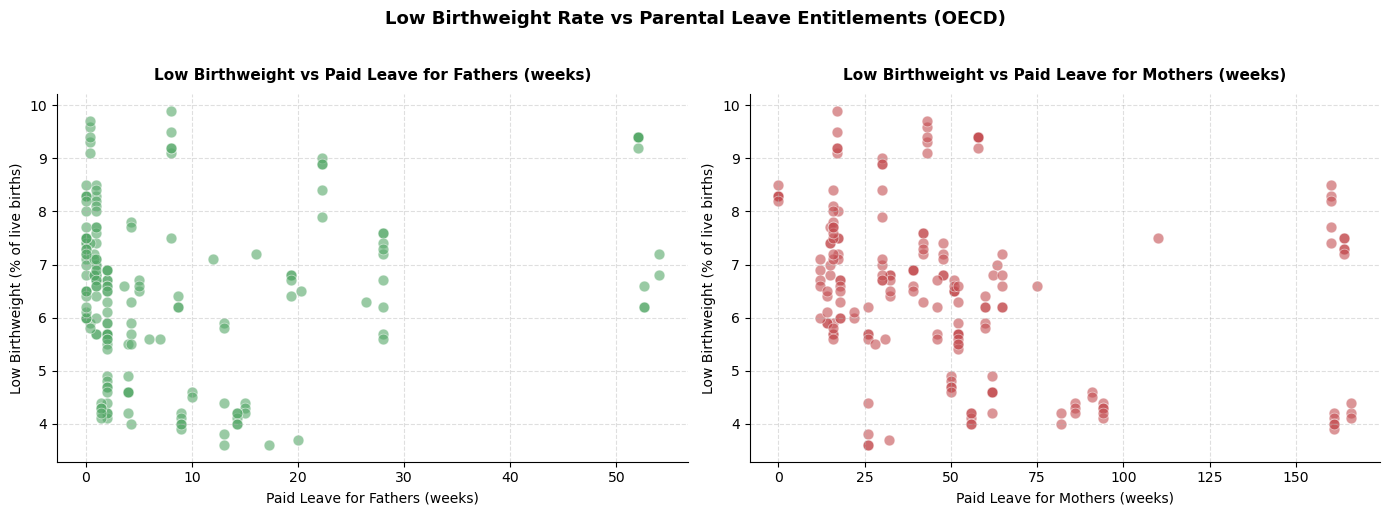

In [8]:
# Plot 2: Customized scatter plot of primary policy variables
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter_vars = [
    ('leave_fathers', 'Paid Leave for Fathers (weeks)', '#55A868'),
    ('leave_mothers', 'Paid Leave for Mothers (weeks)', '#C44E52')
]

for ax, (x_var, x_label, color) in zip(axes, scatter_vars):
    ax.scatter(merged[x_var], merged['lowb_pct'], color=color, alpha=0.6, edgecolors='white', linewidth=0.5, s=60)
    ax.set_xlabel(x_label, fontsize=10)
    ax.set_ylabel('Low Birthweight (% of live births)', fontsize=10)
    ax.set_title(f'Low Birthweight vs {x_label}', fontsize=11, fontweight='bold', pad=10)
    ax.grid(linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Low Birthweight Rate vs Parental Leave Entitlements (OECD)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [9]:
import statsmodels.formula.api as smf

reg_vars = ['leave_fathers', 'leave_mothers']

for x_var in reg_vars:
    model = smf.ols(f'lowb_pct ~ {x_var}', data=merged.dropna(subset=[x_var, 'lowb_pct'])).fit()
    coef = model.params[x_var]
    se = model.bse[x_var]
    print(f"lowb_pct ~ {x_var}")
    print(f"  Coefficient: {coef:.4f}")
    print(f"  Std Error:   {se:.4f}")
    print()

lowb_pct ~ leave_fathers
  Coefficient: 0.0158
  Std Error:   0.0086

lowb_pct ~ leave_mothers
  Coefficient: -0.0099
  Std Error:   0.0026



- *Extra Credit: Write your visualization and regression interpretations here*

### **Submission Checklist**

- **Out-of-the-Box Execution**
  - Select `Kernel -> Restart & Run All` to verify all cells run without error.
- **Reproducibility & Paths**
  - Verify that both the notebook and the dataset are saved and committed in Git.
  - Ensure all files are loaded using relative paths.
- **Visual Elements & Design**
  - Ensure all plots are fully customized, clearly labeled, and have titles.